#### Business Questions
> Which state generates the highest sales?

> Which product category is most profitable?

> Which products generate the highest revenue?

> Which payment method is used the most?

> What is the monthly sales trend?


#### `Step 0 :- Import Libraries`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### `Step 1 :- Load Dataset`

In [2]:
data_frame = pd.read_excel('Project_2_Ecommerce_Data_Analyst.xlsx')

# Quick look at data
print(f'Shape: {data_frame.shape}')

print(f'Total Columns:\n{data_frame.columns}')

data_frame.head()

Shape: (15000, 12)
Total Columns:
Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Product_Category',
       'Product_Name', 'State', 'City', 'Payment_Mode', 'Quantity',
       'Sales_Amount', 'Discount', 'Profit'],
      dtype='str')


,Order_ID,Order_Date,Customer_ID,Product_Category,Product_Name,State,City,Payment_Mode,Quantity,Sales_Amount,Discount,Profit
0,ORD100000,2023-07-11,CUST8187,Home & Kitchen,Air Fryer,Uttar Pradesh,Chennai,Cash on Delivery,5,1225,0.11,213.18
1,ORD100001,2023-06-28,CUST8470,Electronics,Laptop,Rajasthan,Ahmedabad,Credit Card,3,2355,0.21,312.75
2,ORD100002,2024-01-08,CUST3542,Electronics,Camera,Uttar Pradesh,Jaipur,Debit Card,4,1948,0.29,118.10
3,ORD100003,2023-06-28,CUST8975,Electronics,Camera,Rajasthan,Bangalore,Credit Card,1,1438,0.17,284.36
4,ORD100004,2024-03-05,CUST3112,Beauty,Hair Dryer,Rajasthan,Chennai,Net Banking,1,727,0.07,124.67


#### `Step 2 :- Data Cleaning`

In [3]:
# Remove duplicate records (if any)
print(f'Before removing duplicates: {data_frame.shape}')

data_frame = data_frame.drop_duplicates()

print(f'After removing duplicates: {data_frame.shape}')

# Verify duplicate count
duplicate_count = data_frame.duplicated().sum()

print(f'Remaining duplicate rows: {duplicate_count}')

Before removing duplicates: (15000, 12)
After removing duplicates: (15000, 12)
Remaining duplicate rows: 0


In [4]:
# Check Missing Values
print(f'Missing values before handling:\n{data_frame.isnull().sum()}')

# List of Numeric Columns
numeric_columns = [
    'Quantity',
    'Sales_Amount',
    'Discount',
    'Profit']

# Convert Numeric Columns
for column in numeric_columns:
    data_frame[column] = pd.to_numeric(
        data_frame[column],
        errors = 'coerce')

# Fill Missing Numeric Values
data_frame[numeric_columns] = (
    data_frame[numeric_columns].fillna(0))

# List of Categorical Columns
categorical_columns = [
    'Product_Category',
    'Product_Name',
    'State',
    'City',
    'Payment_Mode']

# Fill Missing Categorical Values
for column in categorical_columns:
    data_frame[column] = data_frame[column].fillna('Unknown')

# Verify Missing Values
print(f'\nMissing values after handling:\n{data_frame.isnull().sum()}')

Missing values before handling:
Order_ID            0
Order_Date          0
Customer_ID         0
Product_Category    0
Product_Name        0
State               0
City                0
Payment_Mode        0
Quantity            0
Sales_Amount        0
Discount            0
Profit              0
dtype: int64

Missing values after handling:
Order_ID            0
Order_Date          0
Customer_ID         0
Product_Category    0
Product_Name        0
State               0
City                0
Payment_Mode        0
Quantity            0
Sales_Amount        0
Discount            0
Profit              0
dtype: int64


In [5]:
# Format Order Date properly
data_frame['Order_Date'] = pd.to_datetime(
    data_frame['Order_Date'],
    errors = 'coerce')

print(f"Order Date dtype: {data_frame['Order_Date'].dtype}")

Order Date dtype: datetime64[us]


In [6]:
# Standardize column names
data_frame.columns = (
    data_frame.columns
    .str.strip()
    .str.replace(' ', '_')
    .str.replace('-', '_'))

print(f'Standardized Columns: {data_frame.columns.tolist()}')

Standardized Columns: ['Order_ID', 'Order_Date', 'Customer_ID', 'Product_Category', 'Product_Name', 'State', 'City', 'Payment_Mode', 'Quantity', 'Sales_Amount', 'Discount', 'Profit']


#### `Step 3 :- Data Analysis`

In [7]:
# Total Sales
total_sales = data_frame['Sales_Amount'].sum()

print(f'Total Sales: {total_sales:,.2f}')

Total Sales: 49,384,840.00


In [8]:
# Total Profit
total_profit = data_frame['Profit'].sum()

print(f'Total Profit: {total_profit:,.2f}')

Total Profit: 7,377,771.09


In [9]:
# Total Orders
total_orders = data_frame['Order_ID'].nunique()

print(f'Total Orders: {total_orders}')

Total Orders: 15000


In [10]:
# Average Discount
average_discount = data_frame['Discount'].mean()

print(f'Average Discount: {average_discount:.2%}')

Average Discount: 15.01%


In [11]:
# Total Quantity Sold
total_quantity = data_frame['Quantity'].sum()

print(f'Total Quantity Sold: {total_quantity:,}')

Total Quantity Sold: 45,191


#### `Step 4 :- Business Analysis`

In [12]:
# Sales by State
sales_state = (
    data_frame.groupby('State')['Sales_Amount']
    .sum()
    .sort_values(ascending = False))

sales_state.reset_index().style.format({'Sales_Amount': '{:,.2f}'})

,State,Sales_Amount
0,Rajasthan,"7,230,100.00"
1,Karnataka,"7,142,955.00"
2,Gujarat,"7,141,494.00"
3,Tamil Nadu,"6,982,897.00"
4,Delhi,"6,969,026.00"
5,Uttar Pradesh,"6,965,893.00"
6,Maharashtra,"6,952,475.00"


In [13]:
# Sales by Product Category
sales_category = (
    data_frame.groupby('Product_Category')['Sales_Amount']
    .sum()
    .sort_values(ascending = False))

sales_category.reset_index().style.format({'Sales_Amount': '{:,.2f}'})

,Product_Category,Sales_Amount
0,Electronics,"10,234,029.00"
1,Clothing,"9,852,771.00"
2,Home & Kitchen,"9,813,312.00"
3,Beauty,"9,761,759.00"
4,Sports,"9,722,969.00"


In [14]:
# Top 10 Products by Sales
top_selling_products = (
    data_frame.groupby('Product_Name')['Sales_Amount']
    .sum()
    .sort_values(ascending = False)
    .head(10))

top_selling_products.reset_index().style.format({'Sales_Amount': '{:,.2f}'})

,Product_Name,Sales_Amount
0,Tablet,"2,205,091.00"
1,Smartphone,"2,148,078.00"
2,Skin Cream,"2,089,872.00"
3,Jeans,"2,081,730.00"
4,Headphones,"2,063,692.00"
5,Vacuum Cleaner,"2,052,444.00"
6,Yoga Mat,"2,029,162.00"
7,Makeup Kit,"2,023,811.00"
8,Air Fryer,"2,012,414.00"
9,Face Wash,"2,004,712.00"


In [15]:
# Most Popular Payment Mode
payment_mode = (
    data_frame.groupby('Payment_Mode')['Order_ID']
    .count()
    .sort_values(ascending = False))

payment_mode.reset_index(name = 'Total_Orders')

,Payment_Mode,Total_Orders
0,Cash on Delivery,3059
1,Credit Card,3024
2,Debit Card,3020
3,Net Banking,2960
4,UPI,2937


In [16]:
# Profit by Product Category
profit_category = (
    data_frame.groupby('Product_Category')['Profit']
    .sum()
    .sort_values(ascending = False))

print(f'Profit by Product Category:\n{profit_category}')

Profit by Product Category:
Product_Category
Electronics       1551194.98
Clothing          1468307.01
Beauty            1459496.16
Sports            1452319.77
Home & Kitchen    1446453.17
Name: Profit, dtype: float64


In [17]:
# Create Year-Month feature
data_frame['Year_Month'] = (
    data_frame['Order_Date'].dt.to_period('M'))

# Calculate monthly sales
monthly_sales = (
    data_frame.groupby('Year_Month', as_index = False)['Sales_Amount']
    .sum())

# Convert Year-Month to string
monthly_sales['Year_Month'] = (
    monthly_sales['Year_Month'].astype(str))

monthly_sales.reset_index().style.format(
    {'Sales_Amount': '{:,.2f}'})

,index,Year_Month,Sales_Amount
0,0,2023-01,"2,139,867.00"
1,1,2023-02,"1,726,147.00"
2,2,2023-03,"2,236,805.00"
3,3,2023-04,"2,053,313.00"
4,4,2023-05,"2,097,662.00"
5,5,2023-06,"1,833,534.00"
6,6,2023-07,"2,179,755.00"
7,7,2023-08,"2,128,516.00"
8,8,2023-09,"2,054,990.00"
9,9,2023-10,"2,052,037.00"


#### `Step 5 :- Dashboard Creation`
> Create visualizations to summarize the business analysis and key performance indicators.

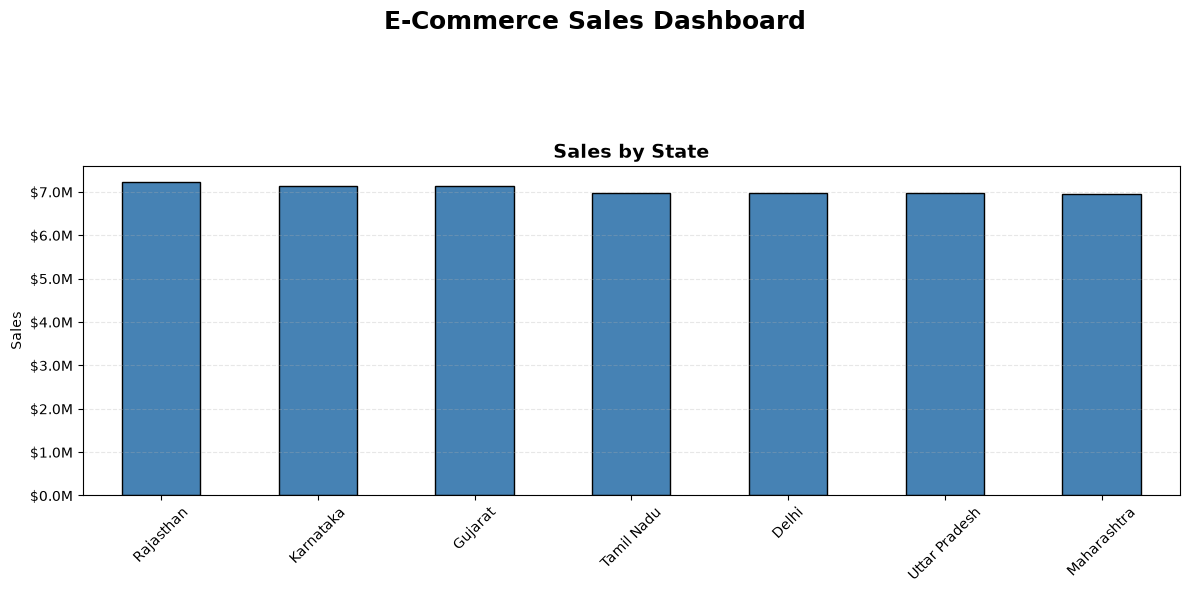

In [18]:
# Create dashboard
dashboard_figure, dashboard_axes = plt.subplots(figsize = (12, 6))

dashboard_figure.patch.set_facecolor('white')

# Dashboard title
dashboard_figure.suptitle(
    'E-Commerce Sales Dashboard',
    fontsize = 18,
    fontweight = 'bold')

# Format Y-axis values
millions_formatter = plt.FuncFormatter(
    lambda x, _: f'${x/1e6:.1f}M')

# Sales by State chart
sales_state.plot(
    kind = 'bar',
    ax = dashboard_axes,
    color = 'steelblue',
    edgecolor = 'black')

dashboard_axes.set_title(
    'Sales by State',
    fontsize = 14,
    fontweight = 'bold')

dashboard_axes.set_xlabel('')
dashboard_axes.set_ylabel('Sales')

dashboard_axes.tick_params(axis = 'x', rotation = 45)

dashboard_axes.grid(axis = 'y', linestyle = '--', alpha = 0.3)

dashboard_axes.yaxis.set_major_formatter(millions_formatter)

plt.tight_layout(rect = [0, 0, 1, 0.85])

plt.savefig(
    '2_Project_1_Chart.png',
    dpi = 300,
    bbox_inches = 'tight')

plt.show()

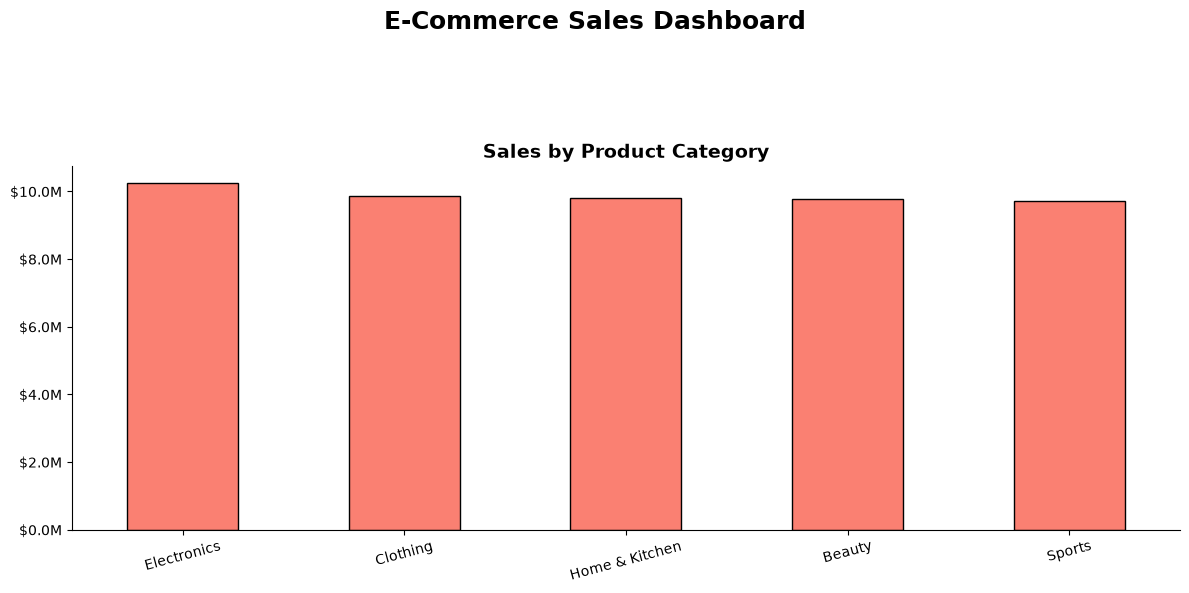

In [19]:
# Create dashboard
dashboard_figure, dashboard_axes = plt.subplots(figsize = (12, 6))

dashboard_figure.patch.set_facecolor('white')

dashboard_figure.suptitle(
    'E-Commerce Sales Dashboard',
    fontsize = 18,
    fontweight = 'bold')

millions_formatter = plt.FuncFormatter(
    lambda x, _: f'${x/1e6:.1f}M')

sales_category.plot(
    kind = 'bar',
    ax = dashboard_axes,
    color = 'salmon',
    edgecolor = 'black')

dashboard_axes.set_title(
    'Sales by Product Category',
    fontsize = 14,
    fontweight = 'bold')

dashboard_axes.set_xlabel('')

dashboard_axes.tick_params(axis = 'x', rotation = 15)

dashboard_axes.spines['top'].set_visible(False)
dashboard_axes.spines['right'].set_visible(False)

dashboard_axes.yaxis.set_major_formatter(millions_formatter)

plt.tight_layout(rect = [0, 0, 1, 0.85])

plt.savefig(
    '2_Project_2_Chart.png',
    dpi = 300,
    bbox_inches = 'tight',
    facecolor = dashboard_figure.get_facecolor())

plt.show()

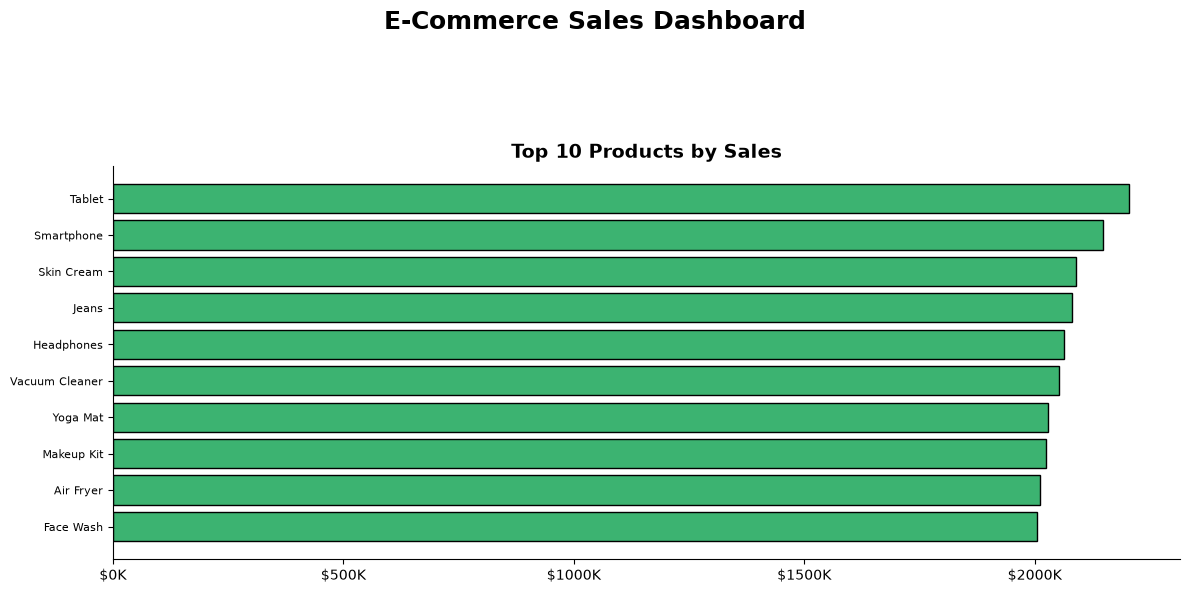

In [20]:
# Create dashboard
dashboard_figure, dashboard_axes = plt.subplots(figsize = (12, 6))

dashboard_figure.patch.set_facecolor('white')

dashboard_figure.suptitle(
    'E-Commerce Sales Dashboard',
    fontsize = 18,
    fontweight = 'bold')

thousands_formatter = plt.FuncFormatter(
    lambda x, _: f'${x/1000:.0f}K')

short_product_names = [
    product_name[:35] + '...'
    if len(product_name) > 35
    else product_name
    for product_name in top_selling_products.index]

dashboard_axes.barh(
    range(len(top_selling_products)),
    top_selling_products.values[::-1],
    color = 'mediumseagreen',
    edgecolor = 'black')

dashboard_axes.set_yticks(range(len(top_selling_products)))
dashboard_axes.set_yticklabels(short_product_names[::-1], fontsize = 8)

dashboard_axes.set_title(
    'Top 10 Products by Sales',
    fontsize = 14,
    fontweight = 'bold')

dashboard_axes.spines['top'].set_visible(False)
dashboard_axes.spines['right'].set_visible(False)

dashboard_axes.xaxis.set_major_formatter(thousands_formatter)

plt.tight_layout(rect = [0, 0, 1, 0.85])

plt.savefig(
    '2_Project_3_Chart.png',
    dpi = 300,
    bbox_inches = 'tight',
    facecolor = dashboard_figure.get_facecolor())

plt.show()

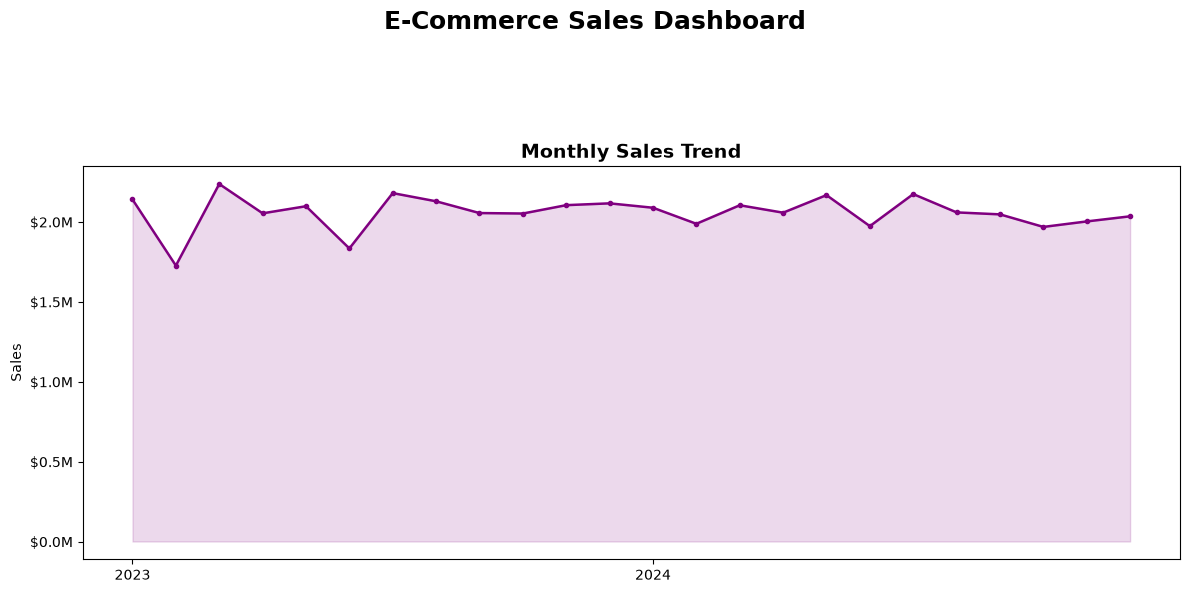

In [25]:
# Create dashboard
dashboard_figure, dashboard_axes = plt.subplots(figsize = (12, 6))

dashboard_figure.patch.set_facecolor('white')

dashboard_figure.suptitle(
    'E-Commerce Sales Dashboard',
    fontsize = 18,
    fontweight = 'bold')

millions_formatter = plt.FuncFormatter(
    lambda x, _: f'${x/1e6:.1f}M')

month_positions = range(len(monthly_sales))

dashboard_axes.fill_between(
    month_positions,
    monthly_sales['Sales_Amount'],
    alpha = 0.15,
    color = 'purple')

dashboard_axes.plot(
    month_positions,
    monthly_sales['Sales_Amount'],
    color = 'purple',
    linewidth = 1.8,
    marker = 'o',
    markersize = 3)

year_tick_positions = [
    index
    for index, year_month in enumerate(monthly_sales['Year_Month'])
    if year_month.endswith('-01')]

year_tick_labels = [
    monthly_sales['Year_Month'].iloc[index][:4]
    for index in year_tick_positions]

dashboard_axes.set_xticks(year_tick_positions)
dashboard_axes.set_xticklabels(year_tick_labels)

dashboard_axes.set_title(
    'Monthly Sales Trend',
    fontsize = 14,
    fontweight = 'bold')

dashboard_axes.set_ylabel('Sales')

dashboard_axes.tick_params(axis = 'x', rotation = 0)

dashboard_axes.yaxis.set_major_formatter(millions_formatter)

plt.tight_layout(rect = [0, 0, 1, 0.85])

plt.savefig(
    '2_Project_4_Chart.png',
    dpi = 300,
    bbox_inches = 'tight',
    facecolor = dashboard_figure.get_facecolor())

plt.show()

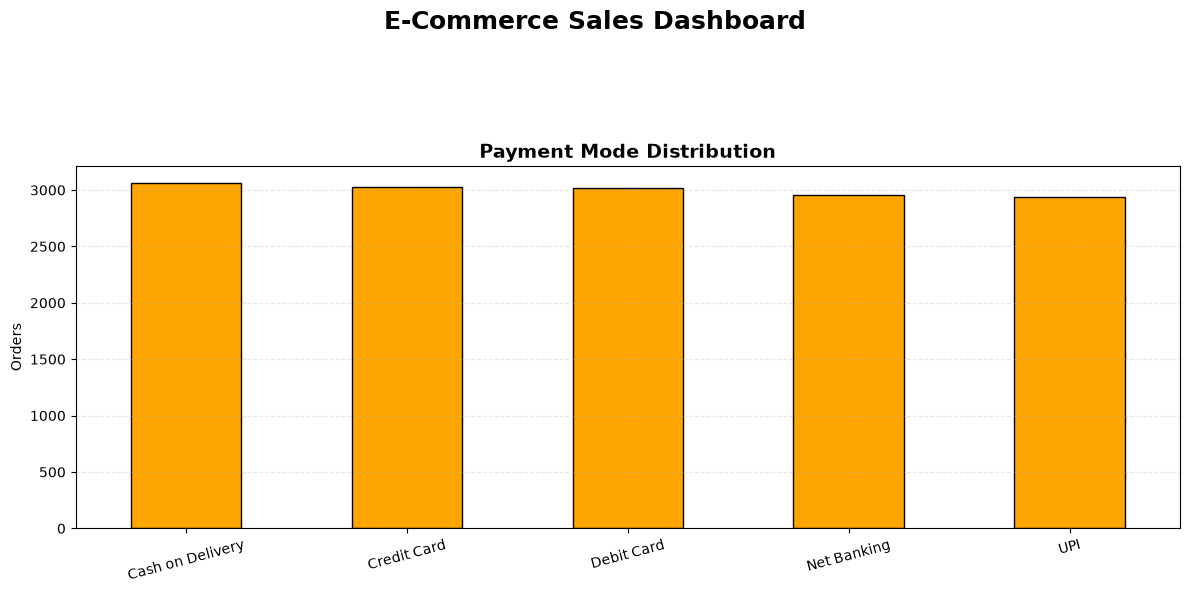

In [22]:
# Create dashboard
dashboard_figure, dashboard_axes = plt.subplots(figsize = (12, 6))

dashboard_figure.patch.set_facecolor('white')

dashboard_figure.suptitle(
    'E-Commerce Sales Dashboard',
    fontsize = 18,
    fontweight = 'bold')

payment_mode.plot(
    kind = 'bar',
    ax = dashboard_axes,
    color = 'orange',
    edgecolor = 'black')

dashboard_axes.set_title(
    'Payment Mode Distribution',
    fontsize = 14,
    fontweight = 'bold')

dashboard_axes.set_xlabel('')
dashboard_axes.set_ylabel('Orders')

dashboard_axes.tick_params(axis = 'x', rotation = 15)

dashboard_axes.grid(axis = 'y', linestyle = '--', alpha = 0.3)

plt.tight_layout(rect = [0, 0, 1, 0.85])

plt.savefig(
    '2_Project_5_Chart.png',
    dpi = 300,
    bbox_inches = 'tight',
    facecolor = dashboard_figure.get_facecolor())

plt.show()

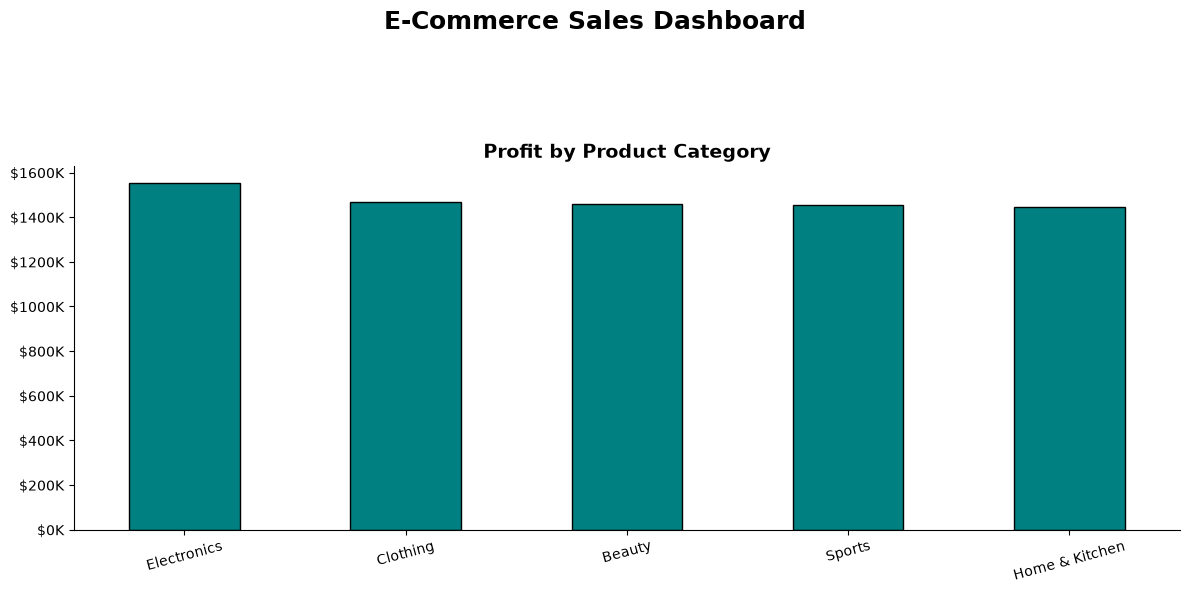

In [23]:
# Create dashboard
dashboard_figure, dashboard_axes = plt.subplots(figsize = (12, 6))

dashboard_figure.patch.set_facecolor('white')

dashboard_figure.suptitle(
    'E-Commerce Sales Dashboard',
    fontsize = 18,
    fontweight = 'bold')

thousands_formatter = plt.FuncFormatter(
    lambda x, _: f'${x/1000:.0f}K')

profit_category.plot(
    kind = 'bar',
    ax = dashboard_axes,
    color = 'teal',
    edgecolor = 'black')

dashboard_axes.set_title(
    'Profit by Product Category',
    fontsize = 14,
    fontweight = 'bold')

dashboard_axes.set_xlabel('')

dashboard_axes.tick_params(axis = 'x', rotation = 15)

dashboard_axes.spines['top'].set_visible(False)
dashboard_axes.spines['right'].set_visible(False)

dashboard_axes.yaxis.set_major_formatter(thousands_formatter)

plt.tight_layout(rect = [0, 0, 1, 0.85])

plt.savefig(
    '2_Project_6_Chart.png',
    dpi = 300,
    bbox_inches = 'tight',
    facecolor = dashboard_figure.get_facecolor())

plt.show()

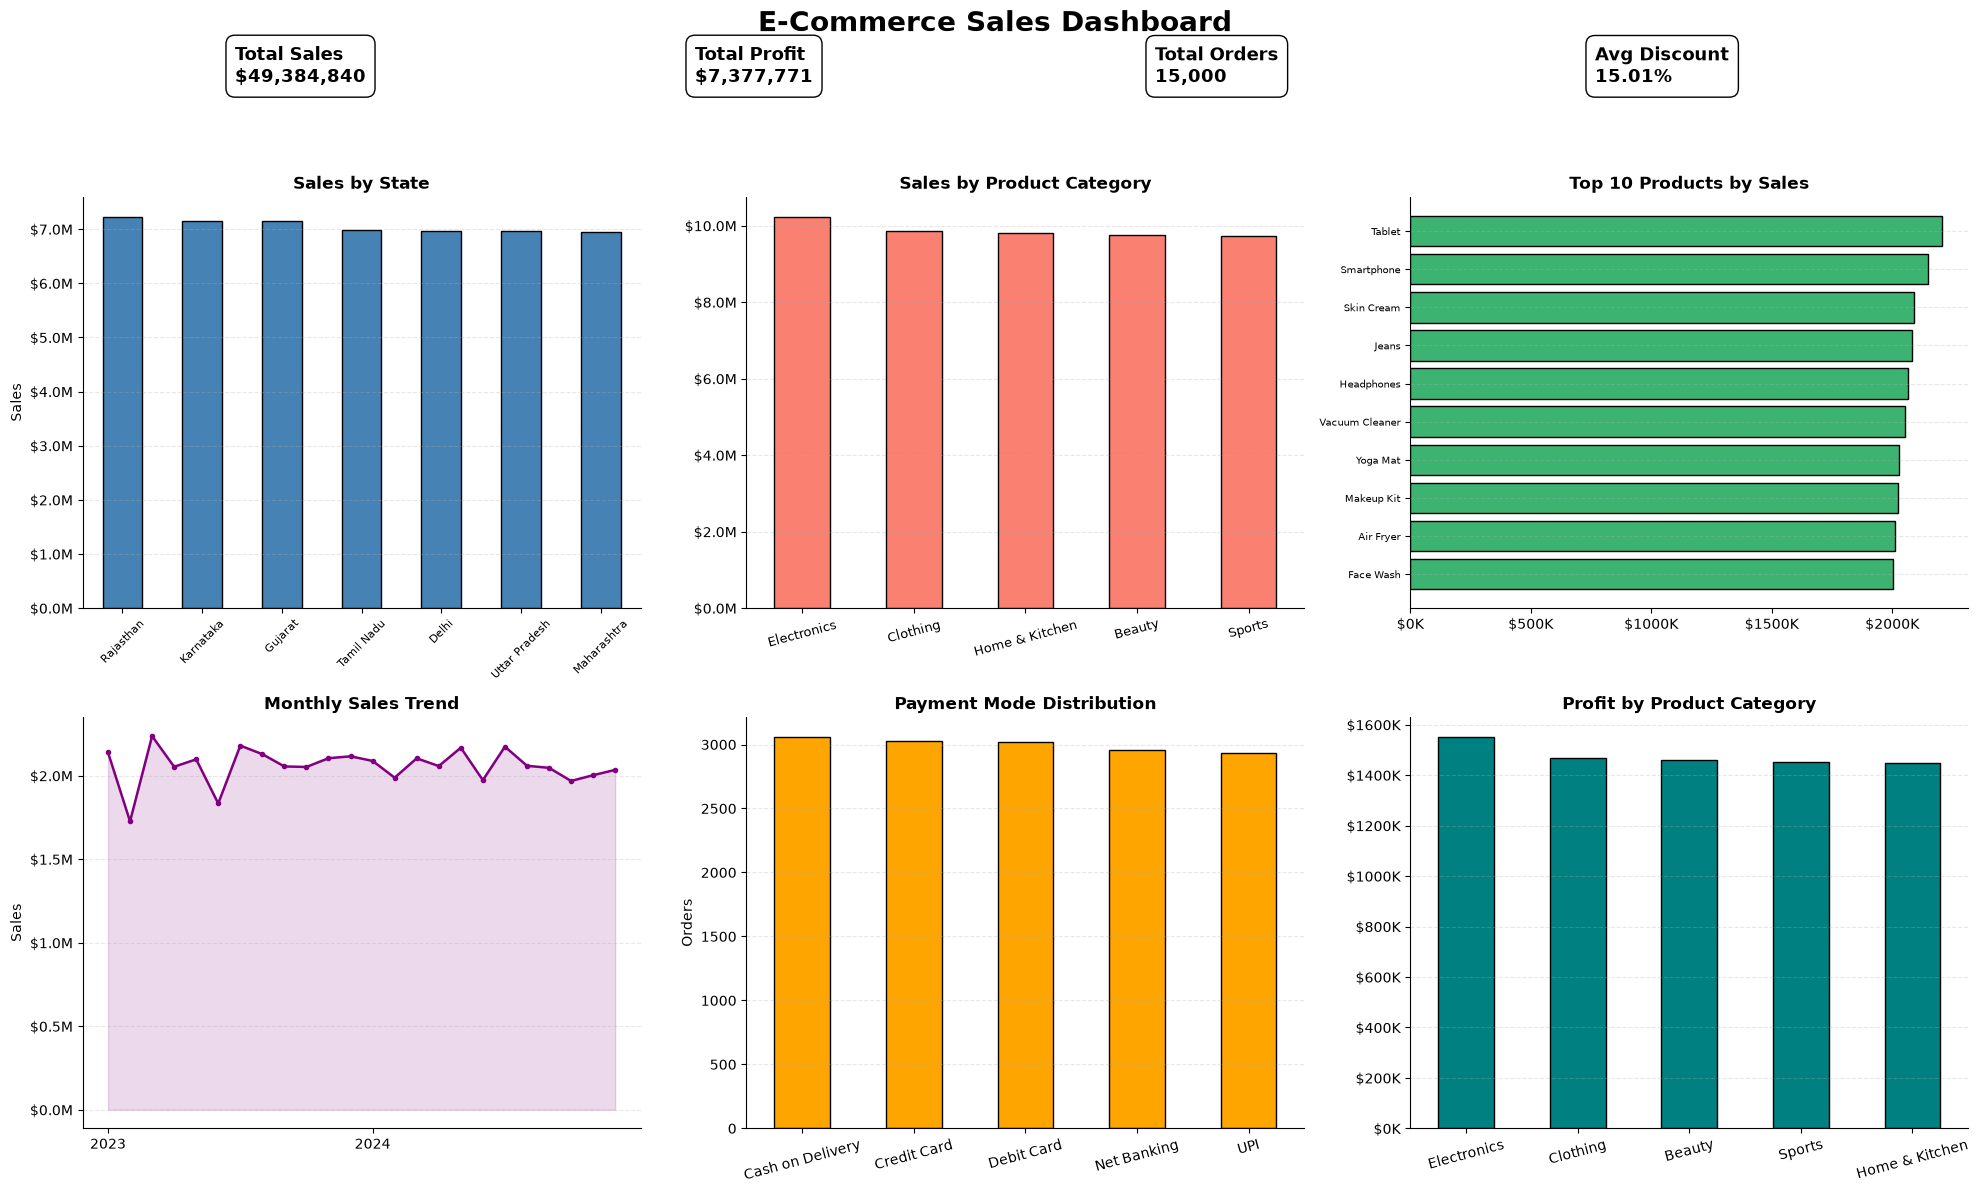

In [24]:
# Create dashboard
dashboard_figure, dashboard_axes = plt.subplots(2, 3, figsize = (20, 12))

# Set background color
dashboard_figure.patch.set_facecolor('white')

# Add dashboard title
dashboard_figure.suptitle(
    'E-Commerce Sales Dashboard',
    fontsize = 20,
    fontweight = 'bold',
    y = 0.99)

# Show KPI cards
dashboard_figure.text(
    0.12, 0.93,
    f'Total Sales\n${total_sales:,.0f}',
    fontsize = 13,
    fontweight = 'bold',
    bbox = dict(facecolor = 'white', edgecolor = 'black', boxstyle = 'round, pad = 0.5'))

dashboard_figure.text(
    0.35, 0.93,
    f'Total Profit\n${total_profit:,.0f}',
    fontsize = 13,
    fontweight = 'bold',
    bbox = dict(facecolor = 'white', edgecolor = 'black', boxstyle = 'round, pad = 0.5'))

dashboard_figure.text(
    0.58, 0.93,
    f'Total Orders\n{total_orders:,}',
    fontsize = 13,
    fontweight = 'bold',
    bbox = dict(facecolor = 'white', edgecolor = 'black', boxstyle = 'round, pad = 0.5'))

dashboard_figure.text(
    0.80, 0.93,
    f'Avg Discount\n{average_discount:.2%}',
    fontsize = 13,
    fontweight = 'bold',
    bbox = dict(facecolor = 'white', edgecolor = 'black', boxstyle = 'round, pad = 0.5'))

# Format chart values
millions_formatter = plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
thousands_formatter = plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')

# Chart 1 : Sales by State
sales_state.plot(
    kind = 'bar',
    ax = dashboard_axes[0, 0],
    color = 'steelblue',
    edgecolor = 'black')

dashboard_axes[0, 0].set_title('Sales by State', fontsize = 12, fontweight = 'bold')
dashboard_axes[0, 0].set_xlabel('')
dashboard_axes[0, 0].set_ylabel('Sales')
dashboard_axes[0, 0].tick_params(axis = 'x', rotation = 45, labelsize = 8)
dashboard_axes[0, 0].yaxis.set_major_formatter(millions_formatter)

# Chart 2 : Sales by Product Category
sales_category.plot(
    kind = 'bar',
    ax = dashboard_axes[0, 1],
    color = 'salmon',
    edgecolor = 'black')

dashboard_axes[0, 1].set_title('Sales by Product Category', fontsize = 12, fontweight = 'bold')
dashboard_axes[0, 1].set_xlabel('')
dashboard_axes[0, 1].tick_params(axis = 'x', rotation = 15, labelsize = 9)
dashboard_axes[0, 1].yaxis.set_major_formatter(millions_formatter)

# Chart 3 : Top 10 Products by Sales
short_product_names = [
    product_name[:35] + '...'
    if len(product_name) > 35
    else product_name
    for product_name in top_selling_products.index
]

dashboard_axes[0, 2].barh(
    range(len(top_selling_products)),
    top_selling_products.values[::-1],
    color = 'mediumseagreen',
    edgecolor = 'black')

dashboard_axes[0, 2].set_yticks(range(len(top_selling_products)))
dashboard_axes[0, 2].set_yticklabels(short_product_names[::-1], fontsize = 7.5)
dashboard_axes[0, 2].set_title('Top 10 Products by Sales', fontsize = 12, fontweight = 'bold')
dashboard_axes[0, 2].xaxis.set_major_formatter(thousands_formatter)

# Chart 4 : Monthly Sales Trend
month_positions = range(len(monthly_sales))

dashboard_axes[1, 0].fill_between(
    month_positions,
    monthly_sales['Sales_Amount'],
    alpha = 0.15,
    color = 'purple')

dashboard_axes[1, 0].plot(
    month_positions,
    monthly_sales['Sales_Amount'],
    color = 'purple',
    linewidth = 1.8,
    marker = 'o',
    markersize = 3)

year_tick_positions = [
    index
    for index, year_month in enumerate(monthly_sales['Year_Month'])
    if year_month.endswith('-01')]

year_tick_labels = [
    monthly_sales['Year_Month'].iloc[index][:4]
    for index in year_tick_positions]

dashboard_axes[1, 0].set_xticks(year_tick_positions)
dashboard_axes[1, 0].set_xticklabels(year_tick_labels, fontsize = 10)
dashboard_axes[1, 0].set_title('Monthly Sales Trend', fontsize = 12, fontweight = 'bold')
dashboard_axes[1, 0].set_ylabel('Sales')
dashboard_axes[1, 0].yaxis.set_major_formatter(millions_formatter)

# Chart 5 : Payment Mode Distribution
payment_mode.plot(
    kind = 'bar',
    ax = dashboard_axes[1, 1],
    color = 'orange',
    edgecolor = 'black')

dashboard_axes[1, 1].set_title('Payment Mode Distribution', fontsize = 12, fontweight = 'bold')
dashboard_axes[1, 1].set_xlabel('')
dashboard_axes[1, 1].set_ylabel('Orders')
dashboard_axes[1, 1].tick_params(axis = 'x', rotation = 15)

# Chart 6 : Profit by Product Category
profit_category.plot(
    kind = 'bar',
    ax = dashboard_axes[1, 2],
    color = 'teal',
    edgecolor = 'black')

dashboard_axes[1, 2].set_title('Profit by Product Category', fontsize = 12, fontweight = 'bold')
dashboard_axes[1, 2].set_xlabel('')
dashboard_axes[1, 2].tick_params(axis = 'x', rotation = 15)
dashboard_axes[1, 2].yaxis.set_major_formatter(thousands_formatter)

# Format all charts
for row in dashboard_axes:
    for chart in row:

        chart.grid(axis = 'y', linestyle = '--', alpha = 0.3)

        chart.spines['top'].set_visible(False)

        chart.spines['right'].set_visible(False)

# Adjust layout
plt.tight_layout(rect = [0, 0, 1, 0.90])

# Save dashboard
plt.savefig(
    '2_Project.png',
    dpi = 300,
    bbox_inches = 'tight',
    facecolor = dashboard_figure.get_facecolor())

# Display dashboard
plt.show()

#### Information

> Dataset: E-Commerce Sales

> Total Rows: 15,000

> Original Columns: 12

> Final Columns: 13

> Added Feature: Year_Month (from Order_Date)

> Missing values and duplicate records were handled properly.

#### Data Insights

> Total Sales: $49.38M

> Total Profit: $7.38M

> Total Quantity Sold: 45,191

> Rajasthan generated the highest sales.

> Electronics generated the highest profit.

> Cash on Delivery was the most used payment method.

#### Business Insights

> Rajasthan is the best-performing state.

> Electronics is the most profitable category.

> Cash on Delivery is the preferred payment method.

> Monthly sales remained stable throughout the period.

> Top-selling products contribute significantly to total sales.

#### Risks

> High dependence on Electronics category.

> Sales are lower in some states.

> Heavy reliance on one payment method.

#### Opportunities

> Increase sales in low-performing states.

> Promote high-profit product categories.

> Improve marketing for low-selling products.

#### Recommendations

> Increase investment in the Electronics category.

> Focus marketing on high-performing states.

> Improve sales in low-performing states.

> Promote multiple payment options.

> Continue monitoring monthly sales trends.

#### Expected Business Impact

> Increase sales.

> Improve profitability.

> Better regional performance.

> Better customer experience.

#### Future Prediction

> Electronics, Cash on Delivery, and Rajasthan are expected to remain strong contributors if current sales trends continue.